# ***UnSupervised Models + SVM***

In [ ]:
# Library
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder , LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score ,confusion_matrix, roc_curve, auc , silhouette_score
from sklearn.model_selection import RandomizedSearchCV , GridSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage , fcluster
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_blobs

In [ ]:
# conect drive file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# *Part A – Supervised Model: SVM*


> ***Data Preprocessing***

In [ ]:
path = '/content/drive/MyDrive/adult.csv'
adult = pd.read_csv(path)
adult

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
# Find Missing Values ... (result: there is no missing values)
adult.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
# (there are many data values with ? sign)  ... Find how many ? Values
( adult == "?").sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [ ]:
# Impute categorical columns with 'most_frequent' strategy
simple_cat = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

# Apply imputation to relevant columns
adult['workclass'] = simple_cat.fit_transform(adult[['workclass']]).ravel()
adult['occupation'] = simple_cat.fit_transform(adult[['occupation']]).ravel()
adult['native-country'] = simple_cat.fit_transform(adult[['native-country']]).ravel()
adult

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
# label encoding for (income); convert  <=50K to 1 & >50K to 0
lable_income = LabelEncoder()
adult['income'] = lable_income.fit_transform(adult['income'])
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0


In [ ]:
# Encode categorical columns using label encoding
categorical_col = ['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'gender', 'native-country']
label_encoder = LabelEncoder()
for col in categorical_col:
    adult[col] = label_encoder.fit_transform(adult[col])

# Display
adult

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,4,226802,1,7,4,7,3,2,1,0,0,40,39,0
1,38,4,89814,11,9,2,5,0,4,1,0,0,50,39,0
2,28,2,336951,7,12,2,11,0,4,1,0,0,40,39,1
3,44,4,160323,15,10,2,7,0,2,1,7688,0,40,39,1
4,18,0,103497,15,10,4,0,3,4,0,0,0,30,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,4,257302,7,12,2,13,5,4,0,0,0,38,39,0
48838,40,4,154374,11,9,2,7,0,4,1,0,0,40,39,1
48839,58,4,151910,11,9,6,1,4,4,0,0,0,40,39,0
48840,22,4,201490,11,9,4,1,3,4,1,0,0,20,39,0


In [ ]:
#Separate features (X) and target (y)
# Using the 'adult' DataFrame after label encoding the categorical columns
X_adult = adult.drop('income', axis=1)
y_adult = adult['income']

In [ ]:
# (( Split the data into training and testing sets "70% train, 30% test" ))
X_adult_test, X_adult_train, y_adult_test, y_adult_train = train_test_split(X_adult, y_adult, test_size=0.3, random_state=42)

In [ ]:
from imblearn.over_sampling import SMOTE
# Balance the (minority-majority) classes in data to be *"sensitive to the minority class"*
bal = SMOTE(random_state=42)
X_adult_train, y_adult_train = bal.fit_resample(X_adult_train, y_adult_train)

In [ ]:
# Standardize
scaler = StandardScaler()
# just select numerical column
num_of_col = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
X_adult_train_scaled = scaler.fit_transform(X_adult_train[num_of_col])
X_adult_test_scaled = scaler.transform(X_adult_test[num_of_col])



> ***Adult Data Models Building & Evaluation then Visualization***



```
#SVM_linear
```

In [ ]:
svm_linear_adult = SVC(kernel='linear', C=1, random_state=45, probability=True)
svm_linear_adult.fit(X_adult_train_scaled, y_adult_train)

SVC(C=10, kernel='linear', probability=True, random_state=45)

In [ ]:
#  Evaluate (Making predictions on the test set)
y_adult_pred_linear = svm_linear_adult.predict(X_adult_test_scaled)
# ((predictions)) vs (actual values)
print("Predicted values:", y_adult_pred_linear)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 1 0]

Actual values: [0 0 0 ... 0 0 1]


In [ ]:
# Compute metrics Linear SVM on Adult dataset
SVM_linear_accuracy = accuracy_score(y_adult_test, y_adult_pred_linear)
SVM_linear_precision = precision_score(y_adult_test, y_adult_pred_linear)
SVM_linear_recall = recall_score(y_adult_test, y_adult_pred_linear)
SVM_linear_f1 = f1_score(y_adult_test, y_adult_pred_linear)
SVM_linear_auc = roc_auc_score(y_adult_test, svm_linear_adult.decision_function(X_adult_test_scaled))

# Print the metrics
print("Accuracy:", SVM_linear_accuracy)
print("Precision:", SVM_linear_precision)
print("Recall:", SVM_linear_recall)
print("F1 Score:", SVM_linear_f1)
print("AUC:", SVM_linear_auc)

Accuracy: 0.7363771973441751
Precision: 0.4718617984308992
Recall: 0.7566227168259344
F1 Score: 0.5812386749059146
AUC: 0.8292855532476597


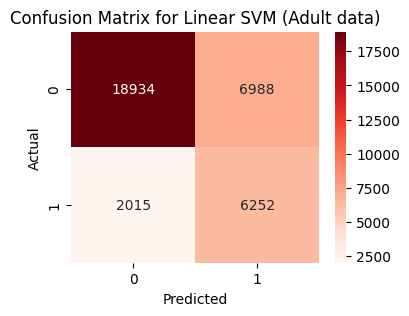

In [ ]:
# confusion matrices for Linear SVM
LinearSVM_cm = confusion_matrix(y_adult_test, y_adult_pred_linear)
plt.figure(figsize=(4, 3))
sns.heatmap(LinearSVM_cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Linear SVM (Adult data)')
plt.show()

```
#SVM_Non Linear {RBF}
```

In [ ]:
svm_rbf_adult = SVC(kernel='rbf', C=1, gamma='scale', probability=True)
svm_rbf_adult.fit(X_adult_train_scaled, y_adult_train)

SVC(C=10, probability=True)

In [ ]:
#  Evaluate the Model
y_adult_pred_Nlinear = svm_rbf_adult.predict(X_adult_test_scaled)
# ((predictions)) vs (actual values)
print("Predicted values:", y_adult_pred_Nlinear)
print()
print("Actual values:", y_adult_test.values)

Predicted values: [0 0 0 ... 0 1 0]

Actual values: [0 0 0 ... 0 0 1]


In [ ]:
# Compute metrics Non-Linear SVM on Adult dataset
SVM_Nlinear_accuracy = accuracy_score(y_adult_test, y_adult_pred_Nlinear)
SVM_Nlinear_precision = precision_score(y_adult_test, y_adult_pred_Nlinear)
SVM_Nlinear_recall = recall_score(y_adult_test, y_adult_pred_Nlinear)
SVM_Nlinear_f1 = f1_score(y_adult_test, y_adult_pred_Nlinear)
SVM_Nlinear_auc = roc_auc_score(y_adult_test, svm_rbf_adult.decision_function(X_adult_test_scaled))

# Print the metrics
print("Accuracy:", SVM_Nlinear_accuracy)
print("Precision:", SVM_Nlinear_precision)
print("Recall:", SVM_Nlinear_recall)
print("F1 Score:", SVM_Nlinear_f1)
print("AUC:", SVM_Nlinear_auc)

Accuracy: 0.743455497382199
Precision: 0.4806659505907626
Recall: 0.7578323454699407
F1 Score: 0.5882352941176471
AUC: 0.8274666211883877


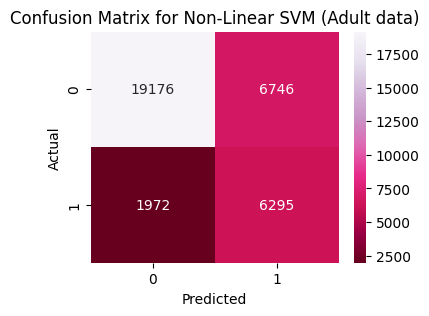

In [ ]:
# confusion matrices for Non-Linear SVM
NLinearSVM_cm = confusion_matrix(y_adult_test, y_adult_pred_Nlinear)
plt.figure(figsize=(4,3))
sns.heatmap(NLinearSVM_cm, annot=True, fmt='d', cmap='PuRd_r')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Non-Linear SVM (Adult data)')
plt.show()

In [ ]:
# Get the predicted probabilities for the positive class for each model
y_adult_pred_prob_linear = svm_linear_adult.predict_proba(X_adult_test_scaled)[:,1]
y_adult_pred_prob_Nlinear = svm_rbf_adult.predict_proba(X_adult_test_scaled)[:,1]

# Calculate the False Positive Rate, True Positive Rate, and thresholds
fpr_linear, tpr_linear, _ = roc_curve(y_adult_test, y_adult_pred_prob_linear)
fpr_Nlinear, tpr_Nlinear, _ = roc_curve(y_adult_test, y_adult_pred_prob_Nlinear)

# Calculate the Area Under the ROC Curve (AUC)
roc_auc_linear_adult = auc(fpr_linear, tpr_linear)
roc_auc_Nlinear_adult = auc(fpr_Nlinear, tpr_Nlinear)

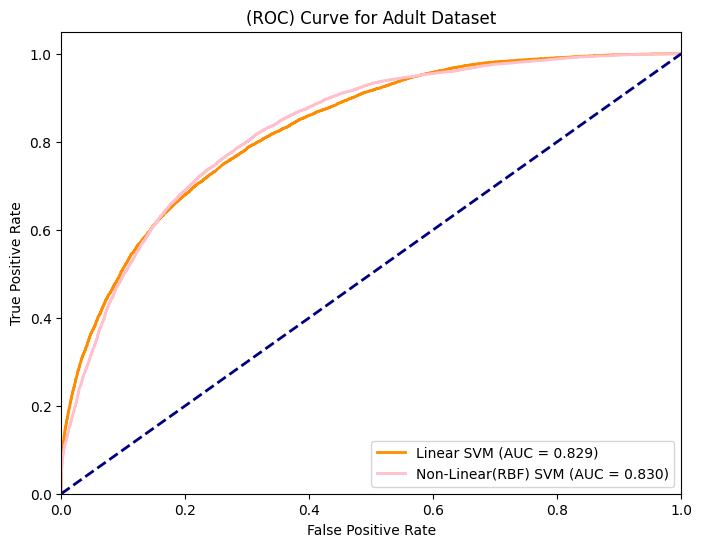

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_linear, tpr_linear, color='darkorange', lw=2, label='Linear SVM (AUC = %0.3f)' % roc_auc_linear_adult)
plt.plot(fpr_Nlinear, tpr_Nlinear, color='pink', lw=2, label='Non-Linear(RBF) SVM (AUC = %0.3f)' % roc_auc_Nlinear_adult)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(ROC) Curve for Adult Dataset')
plt.legend(loc="lower right")
plt.show()

# *Part B – Unsupervised Models: K-Means & Hierarchical Clustering*

> ***Adult Data Preprocessing***

In [ ]:
# data adult
path = '/content/drive/MyDrive/adult.csv'
adult2 = pd.read_csv(path)
adult2

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
# null values
adult2.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
# count ? sign
( adult2 == "?").sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [ ]:
# andle ? sign
adult2 = adult2.replace('?', np.nan)
adult2

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
# Impute categorical columns with 'most_frequent' strategy
simple_cat = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

# Apply imputation to relevant columns
adult2['workclass'] = simple_cat.fit_transform(adult2[['workclass']]).ravel()
adult2['occupation'] = simple_cat.fit_transform(adult2[['occupation']]).ravel()
adult2['native-country'] = simple_cat.fit_transform(adult2[['native-country']]).ravel()
adult2

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
# label encoding for (income); convert  <=50K to 1 & >50K to 0
lable_income = LabelEncoder()
adult2['income'] = lable_income.fit_transform(adult2['income'])
adult2.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,0


In [ ]:
# # Encode categorical columns using label encoding
categorical_col = ['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'gender', 'native-country']
label_encoder = LabelEncoder()
for col in categorical_col:
    adult2[col] = label_encoder.fit_transform(adult2[col])

# Display
adult2

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,1,7,4,6,3,2,1,0,0,40,38,0
1,38,3,89814,11,9,2,4,0,4,1,0,0,50,38,0
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38,1
3,44,3,160323,15,10,2,6,0,2,1,7688,0,40,38,1
4,18,3,103497,15,10,4,9,3,4,0,0,0,30,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,3,257302,7,12,2,12,5,4,0,0,0,38,38,0
48838,40,3,154374,11,9,2,6,0,4,1,0,0,40,38,1
48839,58,3,151910,11,9,6,0,4,4,0,0,0,40,38,0
48840,22,3,201490,11,9,4,0,3,4,1,0,0,20,38,0


In [ ]:
# Drop label
x_adult_unsupervised = adult2.drop('income', axis=1)
y_adult = adult2['income']   # Save labels in a list for validation

In [ ]:
# Scale/standardize
scaler_adult2 = StandardScaler()
X_adult2_scaled = scaler_adult2.fit_transform(x_adult_unsupervised)
X_adult2_scaled

array([[-0.99512893, -0.08972675,  0.35167453, ..., -0.2171271 ,
        -0.03408696,  0.25969378],
       [-0.04694151, -0.08972675, -0.94552415, ..., -0.2171271 ,
         0.77292975,  0.25969378],
       [-0.77631645, -1.8902337 ,  1.3947231 , ..., -0.2171271 ,
        -0.03408696,  0.25969378],
       ...,
       [ 1.41180837, -0.08972675, -0.35751025, ..., -0.2171271 ,
        -0.03408696,  0.25969378],
       [-1.21394141, -0.08972675,  0.11198424, ..., -0.2171271 ,
        -1.64812038,  0.25969378],
       [ 0.97418341,  0.81052673,  0.93049361, ..., -0.2171271 ,
        -0.03408696,  0.25969378]])

> ***Adult Data Models Building & Evaluation then Visualization***

```
# K-Means
```

In [ ]:
# K-means algo
kmeans_adult2 = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_adult2.fit(X_adult2_scaled)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [ ]:
# Evaluate (make predict)
clusters_kmeans_pred_adult2 = kmeans_adult2.predict(X_adult2_scaled)

In [ ]:
# Compute a Silhouette Score.
kmeans_silhouette_adult2 = silhouette_score(X_adult2_scaled, clusters_kmeans_pred_adult2)
print(f"K-Means Silhouette Score (Adult): {kmeans_silhouette_adult2:.4f}")

K-Means Silhouette Score (Adult): 0.1348


In [ ]:
# Compare clusters to true labels with a simple table
table_adult2 = pd.crosstab(y_adult, clusters_kmeans_pred_adult2, rownames=['True Labels'], colnames=['K-Means Clusters'])
print("\nK-Means Cluster vs. True Labels (Adult):")
print(table_adult2)


K-Means Cluster vs. True Labels (Adult):
K-Means Clusters      0      1
True Labels                   
0                 18069  19086
1                 10019   1668




```
# Hierarchical Clustering
```



In [ ]:
# Sampling the data for Hierarchical Clustering
sample_size = 1000
np.random.seed(42)
sample_indices = np.random.choice(X_adult2_scaled.shape[0], size=sample_size, replace=False)
X_sample_adult = X_adult2_scaled[sample_indices]
y_sample_adult = y_adult.iloc[sample_indices]

In [ ]:
# Linkage methods: single, complete, average
linkage_methods = ['single', 'complete', 'average']
hierarchical_results_adult = {}

In [ ]:
for method in linkage_methods:  # Apply AgglomerativeClustering on sampled data
    hierarchical_adult2 = AgglomerativeClustering(n_clusters=2, linkage=method)
    clusters_hierarchical_pred_adult2 = hierarchical_adult2.fit_predict(X_sample_adult)

    # Evaluate on sampled data
    silhouette_avg = silhouette_score(X_sample_adult, clusters_hierarchical_pred_adult2)
    hierarchical_results_adult[method] = silhouette_avg

    # Store the best result for later visualization
    if method == 'complete': # Use complete linkage for the main visualization as it's a good general choice
        best_agg_labels_adult = clusters_hierarchical_pred_adult2
        best_hierarchical_method_adult = method

print("\nAll Hierarchical Clustering Silhouette Scores (Adult - Sampled):")
for method, score in hierarchical_results_adult.items():
    print(f"  {method}: {score:.4f}")


All Hierarchical Clustering Silhouette Scores (Adult - Sampled):
  single: 0.6558
  complete: 0.6558
  average: 0.6558


In [ ]:
# Compare clusters to true labels with a simple table
table_adult2 = pd.crosstab(y_sample_adult, clusters_hierarchical_pred_adult2, rownames=['True Labels'], colnames=['Hierarchical Clusters'])
print("\nK-hierarchical Cluster vs. True Labels (BC):")
print(table_adult2)


K-hierarchical Cluster vs. True Labels (BC):
Hierarchical Clusters    0  1
True Labels                  
0                      769  0
1                      227  4


Text(0, 0.5, 'PCA Component 2')

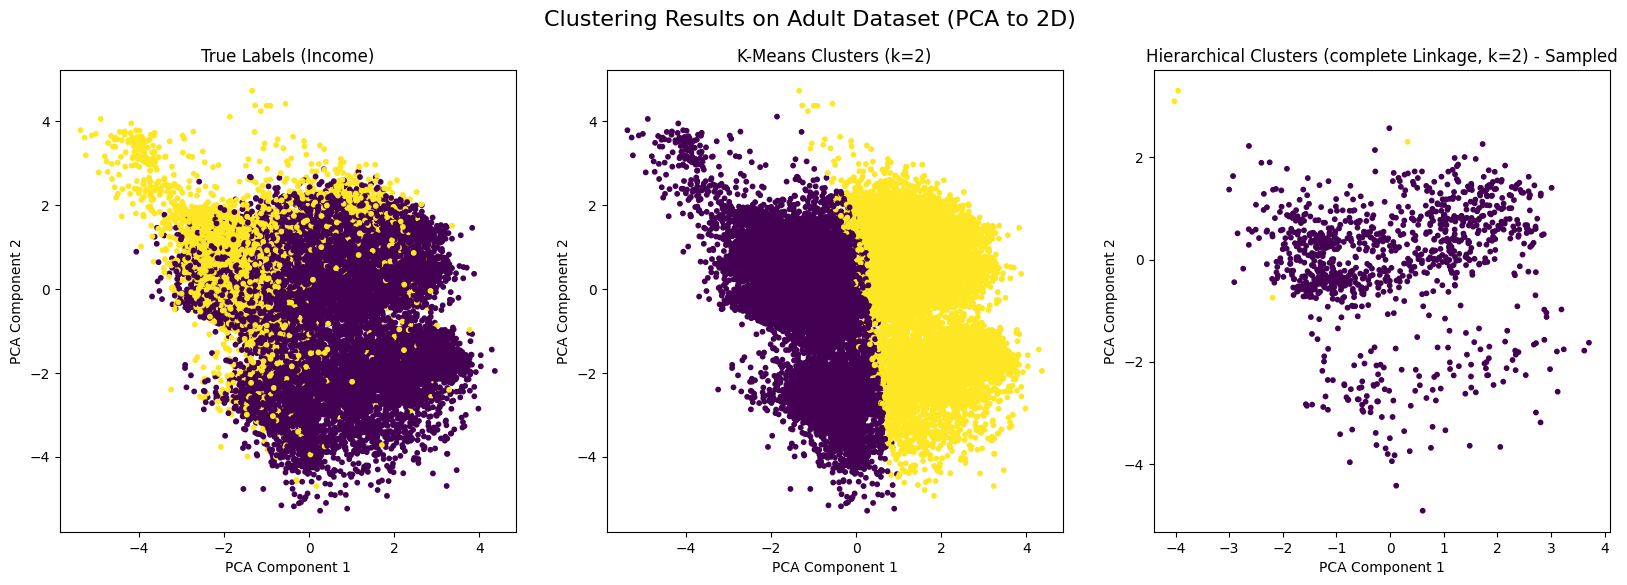

In [ ]:
# Use PCA to 2D and plot ((Reduce dimensionality to 2D using PCA))
pca_adult = PCA(n_components=2)
X_pca_adult = pca_adult.fit_transform(X_adult2_scaled)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Clustering Results on Adult Dataset (PCA to 2D)', fontsize=16)

# Plot 1: True Labels
scatter1 = axes[0].scatter(X_pca_adult[:, 0], X_pca_adult[:, 1], c=y_adult, cmap='viridis', s=10)
axes[0].set_title('True Labels (Income)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

# Plot 2: K-Means Clusters
scatter2 = axes[1].scatter(X_pca_adult[:, 0], X_pca_adult[:, 1], c=clusters_kmeans_pred_adult2, cmap='viridis', s=10)
axes[1].set_title('K-Means Clusters (k=2)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

# Plot 3: Hierarchical Clusters (Sampled Data)
X_pca_sample_adult = X_pca_adult[sample_indices, :]
scatter3 = axes[2].scatter(X_pca_sample_adult[:, 0], X_pca_sample_adult[:, 1], c=best_agg_labels_adult, cmap='viridis', s=10)
axes[2].set_title(f'Hierarchical Clusters ({best_hierarchical_method_adult} Linkage, k=2) - Sampled')
axes[2].set_xlabel('PCA Component 1')
axes[2].set_ylabel('PCA Component 2')

Text(0, 0.5, 'Distance')

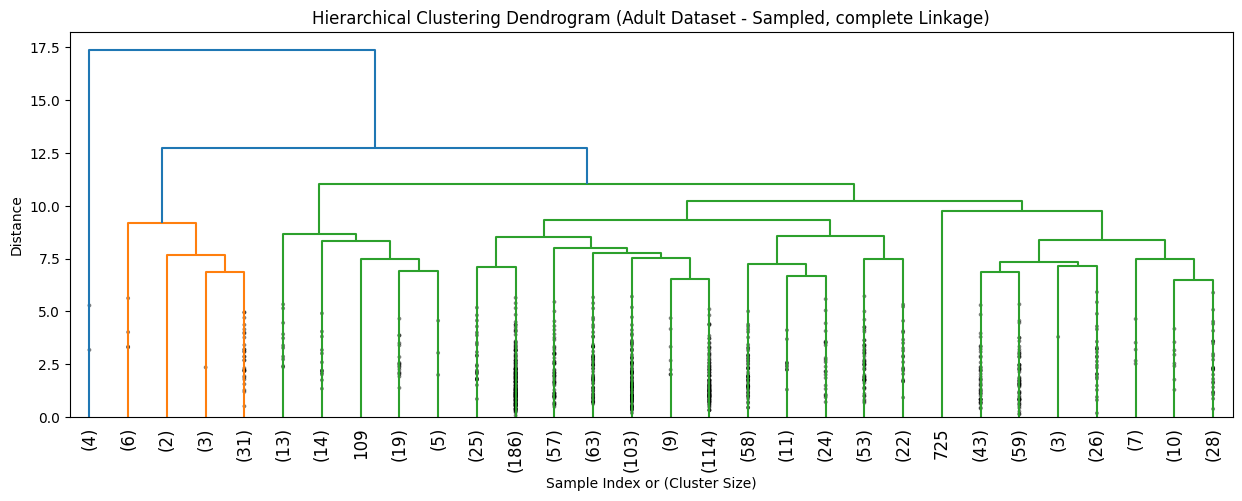

In [ ]:
# --- Dendrogram for Hierarchical Clustering (Sampled Data) ---
linked_adult = linkage(X_sample_adult, method=best_hierarchical_method_adult) # Perform linkage on the sampled data [using the best method]

# Plot the dendrogram
plt.figure(figsize=(15,5))
dendrogram(
    linked_adult,
    orientation='top',
    truncate_mode='lastp',
    p=30,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
)
plt.title(f'Hierarchical Clustering Dendrogram (Adult Dataset - Sampled, {best_hierarchical_method_adult} Linkage)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')